# Introduction to Data Science 2026

# Week 3

## Exercise 1 | Working with geospatial data (GIS)

To get at least a bit familiar with [GIS](https://en.wikipedia.org/wiki/Geographic_information_system) data and the concept of map projections, we’ll do a simple task of plotting two data sets that are given in different coordinate systems.

1. Download the [world_m.zip](https://github.com/HY-TKTL/intro-to-data-science-2017/blob/master/world_m.zip) and [cities.zip](https://github.com/HY-TKTL/intro-to-data-science-2017/blob/master/cities.zip) files that each include a set of GIS files. Most notably, the <span style="font-weight: bold">shp</span> files are [Shapefile-files](https://en.wikipedia.org/wiki/Shapefile) with coordinates (don’t look, it’s binary!). The <span style="font-weight: bold">prj</span> files contain information (in plain text, so okay to look) about the coordinate systems. Open the files using your favorite programming environment and packages.  

    <span style="font-weight: 500"> *Hint: We warmly recommend [Geopandas](http://geopandas.org/) for pythonistas.*</span>

In [1]:
# Use this cell for your code
%pip install geopandas
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file("zip://world_m.zip")
cities = gpd.read_file("zip://cities.zip")

print(world.crs)
print(cities.crs)


[notice] A new release of pip is available: 24.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
EPSG:3395
EPSG:4326


2. The <span style="font-weight: bold">world_m</span> file contains borders of almost all countries in the world. Plot the world.

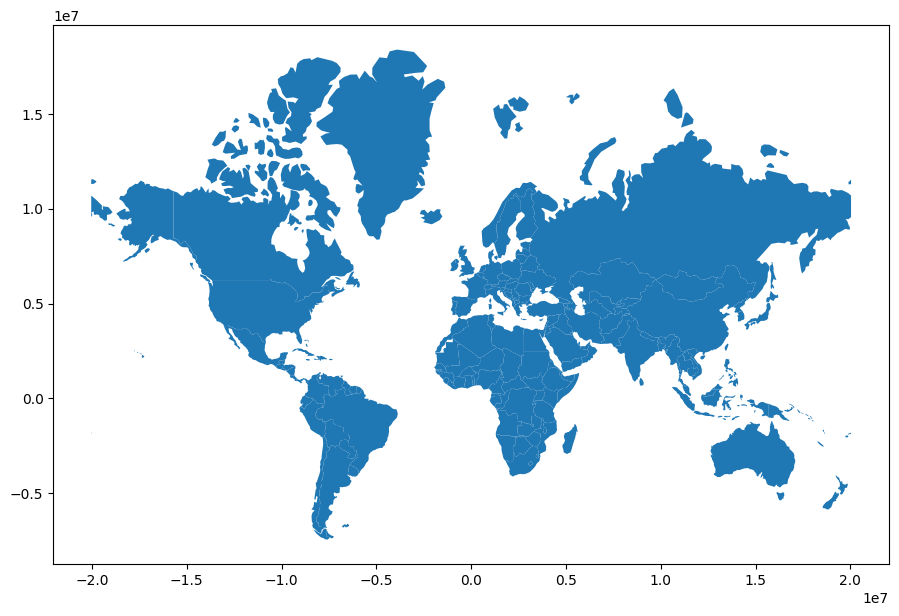

In [2]:
# Use this cell for your code
world.plot(figsize=(12, 7))
plt.show()

3. On top of the countries that you just plotted, plot another layer of information, namely the capital cities of each country from the <span style="font-weight: bold">cities</span> dataset. However, depending on how clever your programming environment is, the cities will probably all appear to be in the Gulf of Guinea, near the coordinates (0°, 0°).

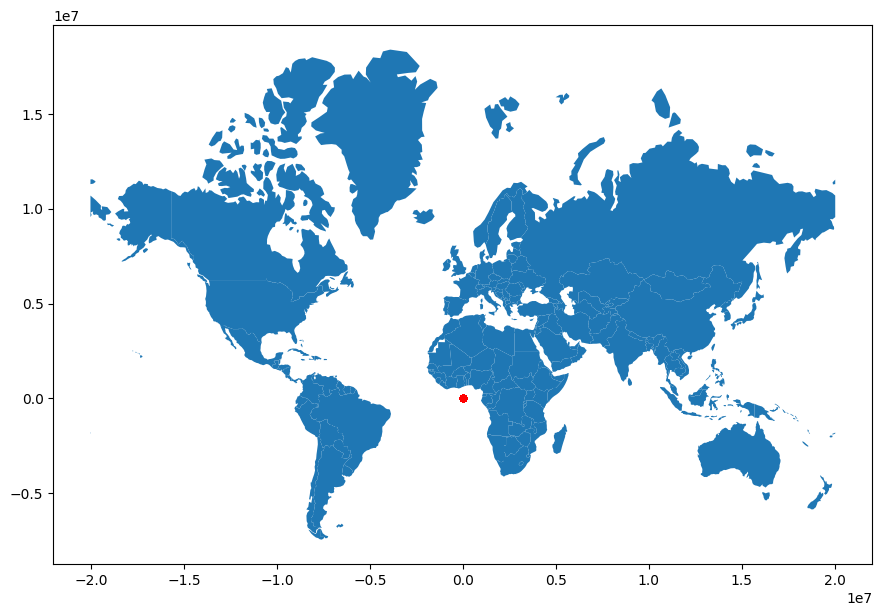

In [8]:
# Use this cell for your code
fig, ax = plt.subplots(figsize=(12, 7))

world.plot(ax=ax)
cities.plot(ax=ax, color="red", markersize=20)

plt.show()

4. Perform a map projection to bring the two data-sets into a shared coordinate system. (You can choose which one.) Now plot the two layers together to make sure the capital cities are where they are supposed to be.

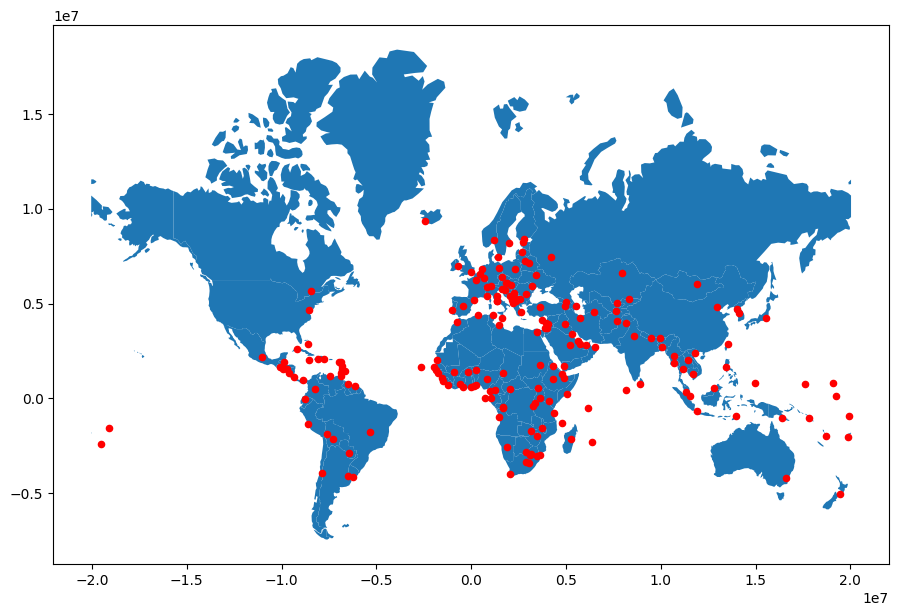

In [6]:
# Use this cell for your code
cities_projected = cities.to_crs(world.crs)

fig, ax = plt.subplots(figsize=(12, 7))

world.plot(ax=ax)
cities_projected.plot(ax=ax, color="red", markersize=20)

plt.show()

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification

We’ll be looking into machine learning by checking out the [HASYv2](https://zenodo.org/record/259444#.Wb7efZ8xDhZ) dataset that contains hand written mathematical symbols as images. The whole dataset is quite big, so we’ll restrict ourselves to doing 10-class classification on some of the symbols. Download the data and complete the following tasks.

1. Extract the data and find inside a file called <span style="font-weight: bold">hasy-data-labels.csv</span>. This file contains the labels for each of the images in the <span style="font-weight: bold">hasy_data</span> folder. Read the labels in and only keep the rows where the <span style="font-weight: bold">symbol_id</span> is within the inclusive range <span style="font-weight: bold">[70, 79]</span>. Read the corresponding images as black-and-white images and flatten them so that each image is a single vector of shape <span style="font-weight: bold">32x32 = 1024</span>. Your dataset should now consist of your input data of shape <span style="font-weight: bold">(1020, 1024)</span> and your labels of shape <span style="font-weight: bold">(1020, )</span>. That is, a matrix of shape <span style="font-weight: bold">1020 x 1024</span> and a vector of size <span style="font-weight: bold">1020</span>.

In [10]:
# Use this cell for your code
import os
import tarfile
import numpy as np
import pandas as pd
from PIL import Image

extract_dir = "HASYv2"

if not os.path.exists(os.path.join(extract_dir, "hasy-data-labels.csv")):
    with tarfile.open("HASYv2.tar.bz2", "r:bz2") as tar:
        tar.extractall(extract_dir)

labels = pd.read_csv(os.path.join(extract_dir, "hasy-data-labels.csv"))
labels = labels[labels["symbol_id"].between(70, 79)].reset_index(drop=True)

X = []

for path in labels["path"]:
    img_path = os.path.join(extract_dir, path)
    img = Image.open(img_path).convert("L")
    img = np.asarray(img, dtype=np.float32) / 255.0
    X.append(img.flatten())

X = np.array(X)
y = labels["symbol_id"].to_numpy()

print(X.shape)
print(y.shape)

(1020, 1024)
(1020,)


2. Randomly shuffle the data, and then split it into training and test sets, using the first 80% of the data for training and the rest for evaluation.

In [11]:
# Use this cell for your code
rng = np.random.default_rng(42)

indices = rng.permutation(len(X))

X_shuffled = X[indices]
y_shuffled = y[indices]

split = int(0.8 * len(X))

X_train = X_shuffled[:split]
X_test = X_shuffled[split:]

y_train = y_shuffled[:split]
y_test = y_shuffled[split:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(816, 1024)
(204, 1024)
(816,)
(204,)


3. Fit a logistic regression classifier on the data. Note that we have a multi-class classification problem, but logistic regression is a binary classifier. For this reason, you will find useful <span style="font-weight: bold">[Sklearn's "multi_class" attribute](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)</span>. Use a multinomial loss and the softmax function to predict the probability of each class as the outcome.  The classifier should select the class with the highest probability. Most library implementations will do this for you - feel free to use one.

In [12]:
# Use this cell for your code
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver="lbfgs",
    max_iter=2000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

4. In order to evaluate the model, let’s create our own dummy classifier that simply guesses the most common class in the training set (looking at the test set here would be cheating!). Then, evaluate your logistic regression model on the test data, and compare it to the majority class classifier. The logistic regression model should have significantly better accuracy as the dummy model is merely making a guess.

    <span style="font-weight: 500"> *Hint: Sklearn's DummyClassifier( ) might save you a bit of time.*</span>

In [13]:
# Use this cell for your code
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)
dummy_accuracy = accuracy_score(y_test, dummy_pred)

print("Logistic regression accuracy:", logistic_accuracy)
print("Dummy classifier accuracy:", dummy_accuracy)

# the logistic regression classifier performs better than the majority-class dummy classifier. 
# this shows that the model has learned useful information from the image pixels instead of simply guessing the most common class.

Logistic regression accuracy: 0.8823529411764706
Dummy classifier accuracy: 0.12254901960784313


5. Plot some of the images that the logistic classifier misclassified. Can you think of an explanation why they were misclassified? Would you have gotten them right?
    
    <span style="font-weight: 500">*Hint: Matplotlib has a [function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) that can help you with plotting.*</span>

Here are some examples of the syntax used to fit a logistic regression classifier (using Sklearn or statsmodel with Python, or GLM with R):

In [ ]:
#Sklearn (python)

#from sklearn.linear_model import LogisticRegression

#Fit on the training data set, with:
#X : {array-like, sparse matrix}, shape (n_samples, n_features) , n_samples rows x n_features columns
#with attributes that describe each sample.
#y : array-like, shape (n_samples,) , n_samples target values for each sample.

#model = LogisticRegression()
#model.fit(X, y)

In [ ]:
#Statsmodels (python)

#import statsmodels.api as sm
#model = sm.Logit(y, X)

In [ ]:
#GLM (R)

#model <- glm(y ~.,family=binomial(link='logit'), data=X)

Number of misclassified images: 24


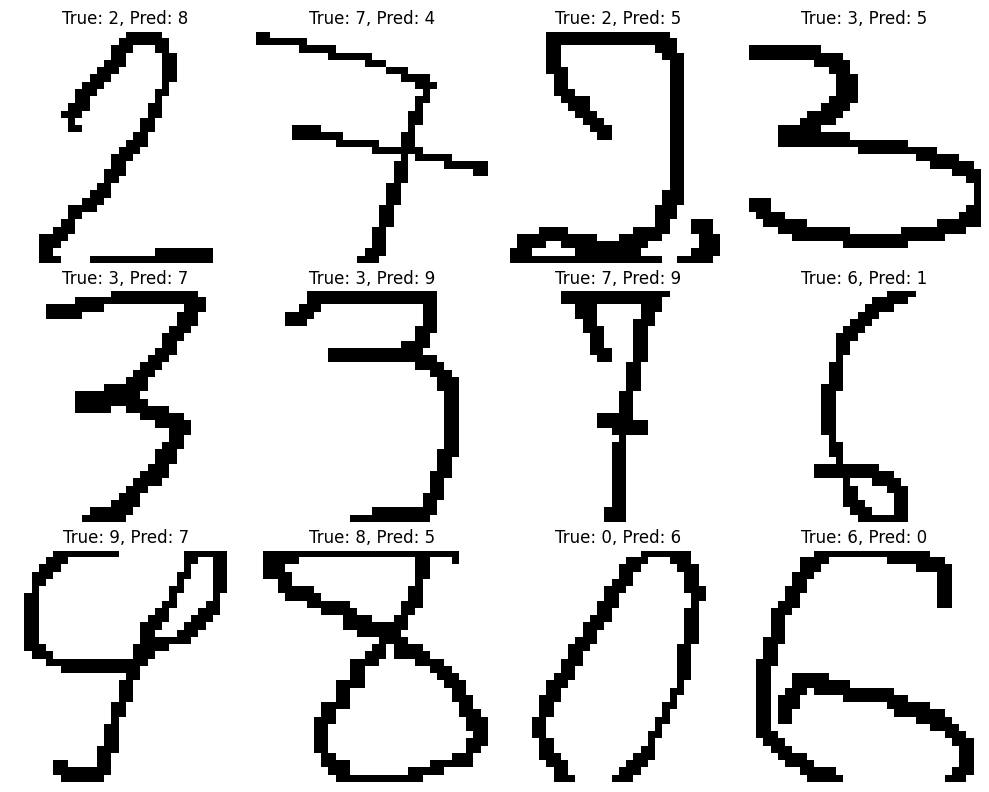

In [15]:
# Use this cell for your code
import matplotlib.pyplot as plt

wrong_indices = np.where(y_pred != y_test)[0]

print("Number of misclassified images:", len(wrong_indices))


fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, i in zip(axes.flat, wrong_indices[:12]):
    ax.imshow(X_test[i].reshape(32, 32), cmap="gray")
    
    true_digit = y_test[i] - 70
    predicted_digit = y_pred[i] - 70
    
    ax.set_title(f"True: {true_digit}, Pred: {predicted_digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Some of the handwritten digits are ambiguous or written in unusual styles, so they look similar to other digits. 
For example, some 3s resemble 5s or 9s, and some 6s resemble 0s. 
Logistic regression is also a relatively simple linear classifier, so it cannot capture complex shapes very well. 
Some of these examples would also be difficult for me to classify correctly.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**